# Italy AI Governance — Coverage Heatmap
**Hackathon Phase 2–3 deliverable**  
Maps 7 Italian AI actors against 5 EU AI Act governance pillars.  
Score 0–3 = coverage/activity level. Outlined cells = non-profit intervention flags.

**How to use:**
1. Edit `data` dict below to update scores.
2. Add/remove actors or pillars freely — the plot auto-scales.
3. Update `flags` list to highlight different cold spots.
4. Run all cells → PNG exported to `italy_heatmap.png`.

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Score matrix
Edit scores here. `0` = gap/absent, `1` = weak/emerging, `2` = moderate, `3` = strong coverage.

In [2]:
# ── Score matrix — Temporal Edition ──────────────────────────────────────────
# Each cell now carries: mandate, activity_type, last_year, maturity, reach, source
# Final score = f(mandate, activity_weight, reach, recency_decay)

import pandas as pd

CURRENT_YEAR = 2025
DECAY_BASE   = 0.88   # 12% penalty per dormant year — adjust to taste

ACTIVITY_WEIGHTS = {
    'ongoing_enforcement': 1.0,   # Active with documented enforcement outcomes
    'active_soft':         0.7,   # Active but advisory / non-binding
    'one_off_position':    0.4,   # Single publication, no follow-up
    'expired_dormant':     0.1,   # Was active, no continuation evidence
}

MATURITY_LEVELS = {
    'audited': 3,   # External review confirms measurable outputs
    'scaled':  2,   # Deployed beyond pilot, institutional ownership
    'pilot':   1,   # Initial implementation, limited scope
    'none':    0,   # Policy exists on paper only / absent
}

# ── Capacity Scores (0=Low, 1=Medium, 2=High, 3=Very High) ───────────────────
CAPACITY_SCORES = {
    'Garante (DPA)':                {'staff': 2, 'budget': 2, 'legal_authority': 3},
    'AgID':                         {'staff': 3, 'budget': 3, 'legal_authority': 3},
    'CDP':                          {'staff': 3, 'budget': 3, 'legal_authority': 2},
    'Corte dei Conti':              {'staff': 3, 'budget': 3, 'legal_authority': 3},
    'Lombardy Region':              {'staff': 3, 'budget': 3, 'legal_authority': 2},
    'Confindustria Digitale':       {'staff': 2, 'budget': 2, 'legal_authority': 1},
    'SME Networks (PMI)':           {'staff': 1, 'budget': 1, 'legal_authority': 0},
    'CDP Venture Capital':          {'staff': 2, 'budget': 3, 'legal_authority': 1},
    'Altroconsumo':                 {'staff': 2, 'budget': 1, 'legal_authority': 1},
    'Trade Unions (CGIL/CISL/UIL)': {'staff': 3, 'budget': 2, 'legal_authority': 2},
    'AIxIA':                        {'staff': 1, 'budget': 1, 'legal_authority': 0},
    'Fondazione Leonardo':          {'staff': 2, 'budget': 2, 'legal_authority': 0},
}

structured_data = {
    # ── GOVERNMENT ──
    'Garante (DPA)': {
        'Risk_Auditing': {'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'scaled', 'reach':1,'source':'ChatGPT ban 2023; OpenAI fine 2024; DeepSeek provisional ban 2025'},
        'Data_Privacy':  {'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'audited','reach':1,'source':'GDPR Art.35 DPIA enforcement; OpenAI €15M fine; DeepSeek 2025'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'one_off_position',   'last_year':2023,'maturity':'pilot',  'reach':0,'source':'AgID collaboration MOU 2023 — no 2024/25 follow-up'},
        'Transparency':  {'mandate':1,'activity_type':'active_soft',        'last_year':2024,'maturity':'pilot',  'reach':0,'source':'Algorithmic transparency guidelines published 2024'},
        'Funding_Grants':{'mandate':0,'activity_type':'one_off_position',   'last_year':2023,'maturity':'none',   'reach':0,'source':'EU Digital Europe institutional grants — no tracked deployment'},
    },
    'AgID': {
        'Risk_Auditing': {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'pilot', 'reach':0,'source':'Piano Triennale ICT 2024-26 risk classification framework'},
        'Data_Privacy':  {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'scaled','reach':0,'source':'Cloud PA security standards; GDPR compliance guidelines'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'active_soft','last_year':2024,'maturity':'pilot', 'reach':0,'source':'AI sandbox for PA pilots 2024 — SME extension not yet launched'},
        'Transparency':  {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'scaled','reach':0,'source':'Linee guida IA nella PA (2024) — binding for public bodies'},
        'Funding_Grants':{'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'scaled','reach':0,'source':'PNRR M1-C1 DigitalizationPA €9.75B — primary executor'},
    },
    'CDP': {
        'Risk_Auditing': {'mandate':0,'activity_type':'expired_dormant','last_year':2021,'maturity':'none','reach':0,'source':'No AI risk framework; ESG mandate does not cover AI'},
        'Data_Privacy':  {'mandate':0,'activity_type':'expired_dormant','last_year':2021,'maturity':'none','reach':0,'source':'Privacy delegated to Garante; no internal AI data governance'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'active_soft',   'last_year':2024,'maturity':'pilot','reach':0,'source':'Fondo Nazionale Innovazione deep-tech SME co-investments'},
        'Transparency':  {'mandate':0,'activity_type':'expired_dormant','last_year':2022,'maturity':'none','reach':0,'source':'No algorithmic disclosure obligations as financial body'},
        'Funding_Grants':{'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'scaled','reach':1,'source':'PNRR M1-C2 Transizione 4.0 €23.89B — primary allocator'},
    },
    'Corte dei Conti': {
        'Risk_Auditing': {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':1,'source':'Judicial tracking of PA algorithms; emerging risk audits'},
        'Data_Privacy':  {'mandate':0,'activity_type':'one_off_position','last_year':2022,'maturity':'none','reach':0,'source':'General PA data handling reviews'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'expired_dormant','last_year':2020,'maturity':'none','reach':0,'source':'No involvement'},
        'Transparency':  {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':0,'source':'Audits on automated decision making in PA'},
        'Funding_Grants':{'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'scaled','reach':1,'source':'Judicial oversight on PNRR AI funds execution'},
    },
    # ── REGIONAL / LOCAL ──
    'Lombardy Region': {
        'Risk_Auditing': {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'pilot','reach':0,'source':'Regional guidelines on AI risks published'},
        'Data_Privacy':  {'mandate':0,'activity_type':'active_soft','last_year':2024,'maturity':'scaled','reach':0,'source':'Regional health data AI privacy rules'},
        'SME_Sandboxes': {'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'scaled','reach':1,'source':'Lombardy AI Hub & active regional testbeds'},
        'Transparency':  {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none','reach':0,'source':'General regional PA transparency'},
        'Funding_Grants':{'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'scaled','reach':1,'source':'Direct regional PNRR & ERDF fund allocation for AI'},
    },
    # ── INDUSTRY ──
    'Confindustria Digitale': {
        'Risk_Auditing': {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none', 'reach':0,'source':'AI Ethics position paper 2023 — no enforcement or follow-up'},
        'Data_Privacy':  {'mandate':0,'activity_type':'active_soft',    'last_year':2024,'maturity':'pilot','reach':0,'source':'GDPR toolkits published for member companies 2024'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'active_soft',    'last_year':2024,'maturity':'pilot','reach':0,'source':'Advocacy for EU AI Act sandbox access; no operational role'},
        'Transparency':  {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none','reach':0,'source':'Voluntary algorithmic transparency charter 2023 — no tracking'},
        'Funding_Grants':{'mandate':0,'activity_type':'active_soft',    'last_year':2024,'maturity':'pilot','reach':0,'source':'Facilitates Transizione 4.0 voucher access for members'},
    },
    'SME Networks (PMI)': {
        'Risk_Auditing': {'mandate':0,'activity_type':'expired_dormant','last_year':2020,'maturity':'none','reach':0,'source':'No risk papers; resource-constrained actors'},
        'Data_Privacy':  {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none','reach':0,'source':'Basic GDPR compliance via Confindustria toolkits only'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'expired_dormant','last_year':2022,'maturity':'none','reach':0,'source':'EU AI Act Art.57 consultations — no PMI representation found'},
        'Transparency':  {'mandate':0,'activity_type':'expired_dormant','last_year':2021,'maturity':'none','reach':0,'source':'No algorithmic disclosure norms for PMIs published'},
        'Funding_Grants':{'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none','reach':0,'source':'Nominally eligible for PNRR Transizione 4.0; structural uptake barriers'},
    },
    'CDP Venture Capital': {
        'Risk_Auditing': {'mandate':0,'activity_type':'expired_dormant','last_year':2021,'maturity':'none','reach':0,'source':'No formal risk checks for portfolio AI startups'},
        'Data_Privacy':  {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none','reach':0,'source':'Basic GDPR compliance checklist for startups'},
        'SME_Sandboxes': {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'scaled','reach':1,'source':'Key gateway & partner for startup innovation sandboxes'},
        'Transparency':  {'mandate':0,'activity_type':'expired_dormant','last_year':2022,'maturity':'none','reach':0,'source':'No algorithmic transparency required from portfolio'},
        'Funding_Grants':{'mandate':1,'activity_type':'ongoing_enforcement','last_year':2025,'maturity':'scaled','reach':1,'source':'Direct AI startup fund allocation (e.g. €1B+ AI fund)'},
    },
    # ── CIVIL SOCIETY ──
    'Altroconsumo': {
        'Risk_Auditing': {'mandate':0,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':0,'source':'Consumer risk advocacy and public awareness campaigns'},
        'Data_Privacy':  {'mandate':1,'activity_type':'active_soft','last_year':2025,'maturity':'scaled','reach':1,'source':'Class actions & advocacy on AI data privacy (e.g., Meta/OpenAI)'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'expired_dormant','last_year':2021,'maturity':'none','reach':0,'source':'Not involved in corporate sandboxes'},
        'Transparency':  {'mandate':1,'activity_type':'active_soft','last_year':2025,'maturity':'pilot','reach':1,'source':'Pushing for algorithmic transparency to protect consumers'},
        'Funding_Grants':{'mandate':0,'activity_type':'expired_dormant','last_year':2020,'maturity':'none','reach':0,'source':'No funding role'},
    },
    'Trade Unions (CGIL/CISL/UIL)': {
        'Risk_Auditing': {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':1,'source':'Negotiating AI risk algorithms in collective bargaining'},
        'Data_Privacy':  {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':0,'source':'Advocating worker data surveillance protections'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'expired_dormant','last_year':2021,'maturity':'none','reach':0,'source':'No presence in AI innovation sandboxes'},
        'Transparency':  {'mandate':1,'activity_type':'active_soft','last_year':2025,'maturity':'pilot','reach':1,'source':'Demanding explainability in HR AI & recruitment tools'},
        'Funding_Grants':{'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none','reach':0,'source':'Consulted on PNRR but no allocation power'},
    },
    # ── ACADEMIA & THINK TANKS ──
    'AIxIA': {
        'Risk_Auditing': {'mandate':1,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':0,'source':'Italian AI Ethics Guidelines; GPAI Code contribution'},
        'Data_Privacy':  {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none','reach':0,'source':'Position statements on data use in AI research — not sustained'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':0,'source':'Academic partner in EU AI Act sandbox pilots 2024'},
        'Transparency':  {'mandate':1,'activity_type':'active_soft','last_year':2025,'maturity':'pilot','reach':0,'source':'Explainability research programme; GPAI WG contribution 2025'},
        'Funding_Grants':{'mandate':0,'activity_type':'active_soft','last_year':2024,'maturity':'pilot','reach':0,'source':'PNRR M4-C2 R&D ecosystem — agenda influence, not direct control'},
    },
    'Fondazione Leonardo': {
        'Risk_Auditing': {'mandate':0,'activity_type':'active_soft',    'last_year':2024,'maturity':'pilot', 'reach':0,'source':'AI & national security risk reports 2023-24 series'},
        'Data_Privacy':  {'mandate':0,'activity_type':'one_off_position','last_year':2023,'maturity':'none', 'reach':0,'source':'Data sovereignty position papers 2023'},
        'SME_Sandboxes': {'mandate':0,'activity_type':'expired_dormant','last_year':2021,'maturity':'none', 'reach':0,'source':'Focus on strategic industries; no SME sandbox engagement'},
        'Transparency':  {'mandate':0,'activity_type':'active_soft',    'last_year':2024,'maturity':'pilot', 'reach':0,'source':'AI accountability chapter in Rapporto Italia 2024'},
        'Funding_Grants':{'mandate':1,'activity_type':'active_soft',    'last_year':2025,'maturity':'scaled','reach':0,'source':'PNRR M4-C1/C2 co-designer with MIUR — eff. €11.44B'},
    },
}

# ── Scoring engine ────────────────────────────────────────────────────────────
def compute_temporal_score(cell, current_year=CURRENT_YEAR, decay_base=DECAY_BASE):
    activity_w  = ACTIVITY_WEIGHTS[cell['activity_type']]
    reach_bonus = 1 + cell['reach']
    raw         = cell['mandate'] + activity_w * reach_bonus
    years_stale = max(0, current_year - cell['last_year'])
    return min(3.0, round(raw * (decay_base ** years_stale), 2))

def maturity_score(cell):
    return MATURITY_LEVELS[cell['maturity']]

pillars = ['Risk_Auditing','Data_Privacy','SME_Sandboxes','Transparency','Funding_Grants']
actors  = list(structured_data.keys())

df_temporal = pd.DataFrame(
    {p: [compute_temporal_score(structured_data[a][p]) for a in actors] for p in pillars},
    index=actors
)
df_capacity = pd.DataFrame.from_dict(CAPACITY_SCORES, orient='index')

# df used by all downstream cells = temporal scores
df = df_temporal.copy()

print("Temporal coverage scores (decay-adjusted):")
print(df_temporal.round(2).to_string())
print("\nCapacity Scores Matrix:")
print(df_capacity.to_string())

Temporal coverage scores (decay-adjusted):
                              Risk_Auditing  Data_Privacy  SME_Sandboxes  Transparency  Funding_Grants
Garante (DPA)                          3.00          3.00           0.31          1.50            0.31
AgID                                   1.50          1.50           0.62          1.50            2.00
CDP                                    0.06          0.06           0.62          0.07            3.00
Corte dei Conti                        2.11          0.27           0.05          1.50            3.00
Lombardy Region                        0.31          0.62           3.00          0.31            3.00
Confindustria Digitale                 0.31          0.62           0.62          0.31            0.62
SME Networks (PMI)                     0.05          0.31           0.07          0.06            0.31
CDP Venture Capital                    0.06          0.31           2.11          0.07            3.00
Altroconsumo                  

## 2 · Export CSV (for reproducibility)

## Problem 2 · PNRR Funding Tracker — Anchoring Scores to Public Budget Records

Instead of estimating the `Funding_Grants` column, this cell derives each score
directly from the official PNRR allocations published on [italiadomani.gov.it](https://italiadomani.gov.it).

Each actor gets an **effective exposure** figure (€M) = raw allocation × governance weight,
where `governance_weight=1.0` = primary allocator, `0.5` = co-designer, `0.25` = indirect facilitator.

In [3]:
# ── Problem 2: PNRR Funding Tracker ──────────────────────────────────────────
# Source: Piano Nazionale di Ripresa e Resilienza — official allocations
# Portal: https://italiadomani.gov.it  |  Data vintage: 2023–2025 revisions

pnrr_allocations = {
    'M1_C1_DigitalizationPA':     9_750,   
    'M1_C2_Transizione40':       23_890,   
    'M1_C2_ConnettivitaBanda':    6_710,   
    'M4_C1_UniversityResearch':  11_440,   
    'M4_C2_RnD_Innovation':      11_440,   
}

# Added the new actors into the funding weight tracker
actor_pnrr = {
    'Garante (DPA)':                {'keys': [], 'w': 0.0},
    'AgID':                         {'keys': ['M1_C1_DigitalizationPA', 'M1_C2_ConnettivitaBanda'], 'w': 0.8},
    'CDP':                          {'keys': ['M1_C2_Transizione40', 'M1_C2_ConnettivitaBanda'], 'w': 1.0},
    'Corte dei Conti':              {'keys': ['M1_C1_DigitalizationPA', 'M1_C2_Transizione40', 'M4_C1_UniversityResearch'], 'w': 0.25}, # Judicial Audit
    'Lombardy Region':              {'keys': ['M1_C1_DigitalizationPA', 'M1_C2_Transizione40'], 'w': 0.5}, # Regional executor
    'Confindustria Digitale':       {'keys': ['M1_C2_Transizione40'], 'w': 0.25},
    'SME Networks (PMI)':           {'keys': [], 'w': 0.0},
    'CDP Venture Capital':          {'keys': ['M1_C2_Transizione40'], 'w': 0.5}, # Direct allocator for startups
    'Altroconsumo':                 {'keys': [], 'w': 0.0},
    'Trade Unions (CGIL/CISL/UIL)': {'keys': [], 'w': 0.0},
    'AIxIA':                        {'keys': ['M4_C2_RnD_Innovation'], 'w': 0.4},
    'Fondazione Leonardo':          {'keys': ['M4_C1_UniversityResearch', 'M4_C2_RnD_Innovation'], 'w': 0.5},
}

passive_scores = {'Garante (DPA)': 1, 'SME Networks (PMI)': 1, 'Altroconsumo': 1, 'Trade Unions (CGIL/CISL/UIL)': 1}

def pnrr_to_score(actor, data):
    eff = sum(pnrr_allocations[k] for k in data['keys']) * data['w']
    if eff == 0:
        return passive_scores.get(actor, 0)
    if eff >= 20_000: return 3
    if eff >= 7_000:  return 2
    return 1

pnrr_scores = {a: pnrr_to_score(a, d) for a, d in actor_pnrr.items()}

# ── Print audit trail ────────────────────────────────────────────────────────
print("PNRR-Backed Funding_Grants Scores")
print("=" * 60)
for actor, data in actor_pnrr.items():
    eff = sum(pnrr_allocations[k] for k in data['keys']) * data['w']
    score = pnrr_scores[actor]
    bar = "■" * score + "□" * (3 - score)
    print(f"  {actor:<28} [{bar}] {score}/3  eff. €{eff/1000:.1f}B")

# Overwrite Funding_Grants column
for actor in df.index:
    if actor in pnrr_scores:
        df.at[actor, 'Funding_Grants'] = pnrr_scores[actor]

PNRR-Backed Funding_Grants Scores
  Garante (DPA)                [■□□] 1/3  eff. €0.0B
  AgID                         [■■□] 2/3  eff. €13.2B
  CDP                          [■■■] 3/3  eff. €30.6B
  Corte dei Conti              [■■□] 2/3  eff. €11.3B
  Lombardy Region              [■■□] 2/3  eff. €16.8B
  Confindustria Digitale       [■□□] 1/3  eff. €6.0B
  SME Networks (PMI)           [■□□] 1/3  eff. €0.0B
  CDP Venture Capital          [■■□] 2/3  eff. €11.9B
  Altroconsumo                 [■□□] 1/3  eff. €0.0B
  Trade Unions (CGIL/CISL/UIL) [■□□] 1/3  eff. €0.0B
  AIxIA                        [■□□] 1/3  eff. €4.6B
  Fondazione Leonardo          [■■□] 2/3  eff. €11.4B


In [4]:
# ── Join capacity metrics before saving ───────────────────────────────────────
df_export = df.join(df_capacity)
df_export.to_csv('italy_ai_governance.csv')
print('CSV saved → italy_ai_governance.csv ✓')

CSV saved → italy_ai_governance.csv ✓


## 3 · Plot — Seaborn heatmap

Saved → italy_heatmap_temporal_mckinsey.png ✓


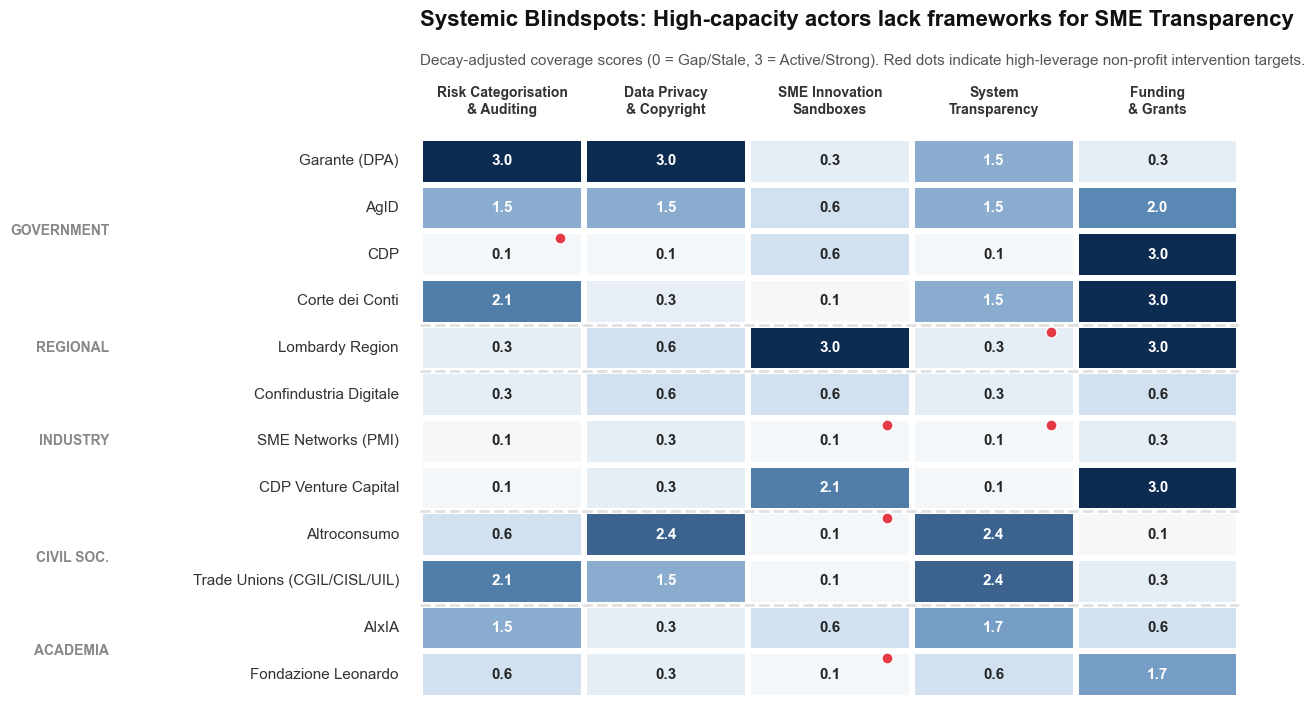

In [11]:

# ─── VARIABLES ───────────────────────────────────────────────────────────────
PILLAR_LABELS = [
    'Risk Categorisation\n& Auditing',
    'Data Privacy\n& Copyright',
    'SME Innovation\nSandboxes',
    'System\nTransparency',
    'Funding\n& Grants',
]

GROUP_SEPARATORS = [4, 5, 8, 10]
GROUP_LABELS = [
    ('GOVERNMENT', 2.0, '#185FA5'),
    ('REGIONAL',   4.5, '#6B3E99'),
    ('INDUSTRY',   6.5, '#3B6D11'),
    ('CIVIL SOC.', 9.0, '#854F0B'),
    ('ACADEMIA',  11.0, '#A51818'),
]

flags = [
    (6, 2), (2, 0), (6, 3), (11, 2), (8, 2), (4, 3)
]

# 1. Define Colormap
prof_cmap = LinearSegmentedColormap.from_list(
    'corporate_blue', ['#F8F9FA', '#B9D1EA', '#5A88B5', '#0C2C52'], N=256
)

# 2. Setup Figure (Made slightly wider at 13x8 for breathing room)
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig, ax = plt.subplots(figsize=(13, 8), facecolor='#FFFFFF')
ax.set_facecolor('#FFFFFF')

# 3. Draw Heatmap
sns.heatmap(
    df_temporal.values.astype(float),
    ax=ax, cmap=prof_cmap, vmin=0, vmax=3, annot=True, fmt='.1f',
    annot_kws={'size': 11, 'weight': 'bold'},
    linewidths=3, linecolor='white', cbar=False           
)

# 4. Clean up Axes 
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# Added 'pad=12' to push the top headers slightly up and away from the heatmap blocks
ax.tick_params(left=False, top=False, bottom=False, pad=12) 

ax.set_xticklabels(PILLAR_LABELS, rotation=0, ha='center', fontsize=10, fontweight='bold', color='#333333')
ax.set_yticklabels(df_temporal.index.tolist(), rotation=0, fontsize=11, fontweight='500', color='#333333')

# 5. Add Horizontal Grouping Separators
for sep in GROUP_SEPARATORS:
    ax.axhline(sep, color='#E0E0E0', linewidth=2, linestyle='--')

# 6. Add Clean Horizontal Group Labels
for label, y, color in GROUP_LABELS:
    # Safely placed at -0.38, but now protected by our manual margins
    ax.text(-0.38, y, label, va='center', ha='right', fontsize=10,
            color='#888888', fontweight='bold', transform=ax.get_yaxis_transform())
    
# 7. Elegant "Opportunity" Flags
for (y, x) in flags:
    ax.plot(x + 0.85, y + 0.15, marker='o', markersize=8, color='#E63946', markeredgecolor='white')

# 8. Insight-Driven Title Block (ANCHORED TO THE AXES, NOT THE FIGURE)
# By using 'transform=ax.transAxes', x=0 is perfectly aligned with the left edge of the blue matrix
ax.text(0, 1.20, "Systemic Blindspots: High-capacity actors lack frameworks for SME Transparency", 
          fontsize=16, fontweight='bold', color='#111111', transform=ax.transAxes)
ax.text(0, 1.13, "Decay-adjusted coverage scores (0 = Gap/Stale, 3 = Active/Strong). Red dots indicate high-leverage non-profit intervention targets.", 
          fontsize=11, color='#555555', transform=ax.transAxes)

# 9. MANUAL LAYOUT OVERRIDE (The Fix)
# We disable tight_layout and manually reserve exactly 32% of the left side for labels, 
# and 25% of the top for headers/titles. This forces the matrix to sit perfectly centered.
plt.subplots_adjust(left=0.32, top=0.75, right=0.95, bottom=0.05)

plt.savefig('italy_heatmap_temporal_mckinsey.png', dpi=300, bbox_inches='tight')
print('Saved → italy_heatmap_temporal_mckinsey.png ✓')
plt.show()

## 3b · Implementation Maturity Heatmap
`0=Paper only → 1=Pilot → 2=Scaled → 3=Externally audited`  
This separates *what is governed* from *how well it is actually implemented*.

Saved → italy_heatmap_maturity_mckinsey.png ✓


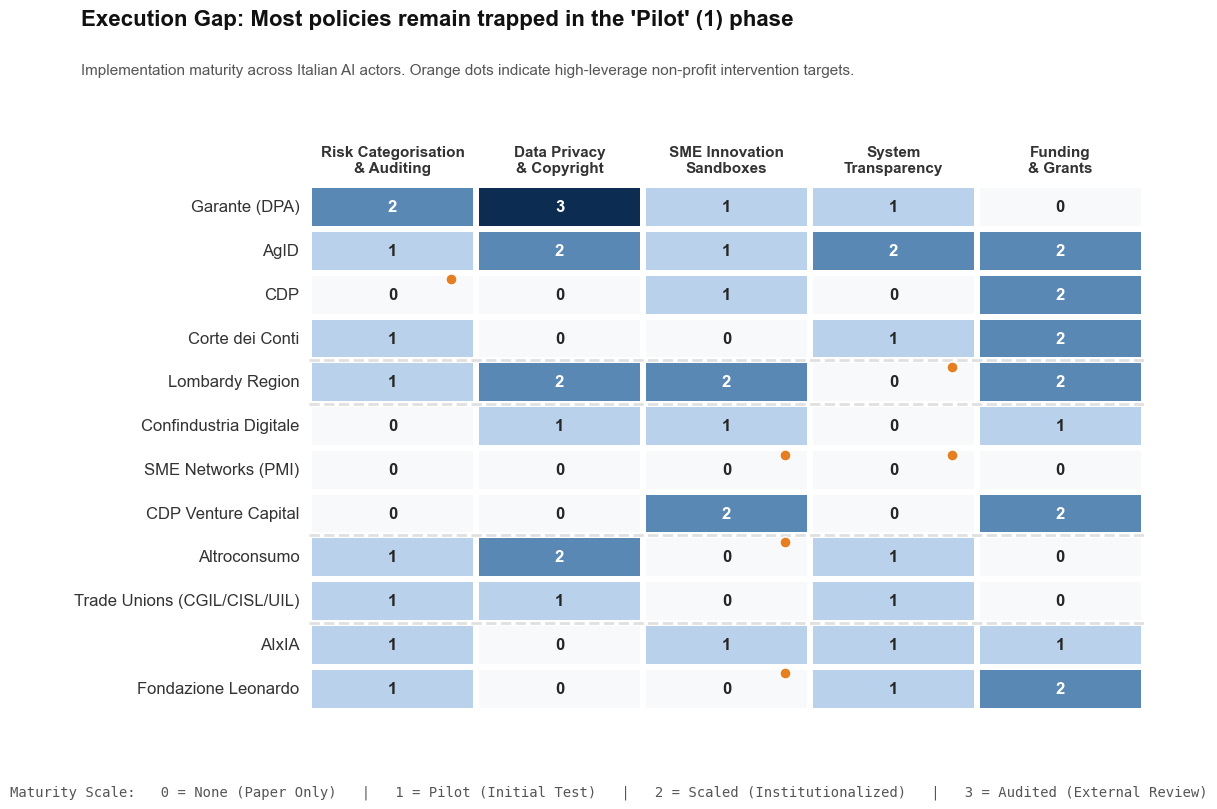

In [14]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

df_maturity = pd.DataFrame(
    {p: [maturity_score(structured_data[a][p]) for a in actors] for p in pillars},
    index=actors
)
# ----------------------------------------------------------------

# 1. Define a strict 4-stage Categorical Colormap
# 0: Light Grey (Paper only) | 1: Pale Blue (Pilot) | 2: Medium Blue (Scaled) | 3: Deep Navy (Audited)
maturity_colors = ['#F8F9FA', '#B9D1EA', '#5A88B5', '#0C2C52']
cmap_mat = ListedColormap(maturity_colors)

# 2. Setup Figure with clean white background
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig2, ax2 = plt.subplots(figsize=(11, 7), facecolor='#FFFFFF')
ax2.set_facecolor('#FFFFFF')

# 3. Draw the Heatmap (Tile Style)
sns.heatmap(
    df_maturity.values.astype(float),
    ax=ax2, 
    cmap=cmap_mat, 
    vmin=-0.5, vmax=3.5, # Centers the discrete colors perfectly
    annot=True, 
    fmt='.0f',
    annot_kws={'size': 12, 'weight': 'bold'},
    linewidths=3,        # Thick white lines for the distinct "tile" look
    linecolor='white',
    cbar=False           # Drop standard colorbar
)

# 4. Clean up the Axes (Consulting rules)
ax2.xaxis.tick_top() # Move column headers to the top
ax2.xaxis.set_label_position('top')
ax2.tick_params(left=False, top=False, bottom=False) # Remove tick marks

# Format Labels
ax2.set_xticklabels(PILLAR_LABELS, rotation=0, ha='center', fontsize=11, fontweight='bold', color='#333333')
ax2.set_yticklabels(df_maturity.index.tolist(), rotation=0, fontsize=12, fontweight='500', color='#333333')

# 5. Add Horizontal Grouping Separators 
GROUP_SEPARATORS = [4, 5, 8, 10]
for y_pos in GROUP_SEPARATORS:
    ax2.axhline(y_pos, color='#E0E0E0', linewidth=2, linestyle='--')

# 6. Elegant "Opportunity" Flags
for (y, x) in flags:
    ax2.plot(x + 0.85, y + 0.15, marker='o', markersize=8, color='#E67E22', markeredgecolor='white')

# 7. Custom Categorical Legend
legend_text = (
    "Maturity Scale:   "
    "0 = None (Paper Only)   |   "
    "1 = Pilot (Initial Test)   |   "
    "2 = Scaled (Institutionalized)   |   "
    "3 = Audited (External Review)"
)
# Moved the legend slightly down by changing the y-coordinate to -0.15
fig2.text(0.5, -0.05, legend_text, fontsize=10, color='#555555', fontfamily='monospace', ha='center')

# 8. Insight-Driven Title Block 
# Anchored to the figure with better spacing
fig2.text(0.02, 1.05, "Execution Gap: Most policies remain trapped in the 'Pilot' (1) phase", 
          fontsize=16, fontweight='bold', color='#111111')
fig2.text(0.02, 0.98, "Implementation maturity across Italian AI actors. Orange dots indicate high-leverage non-profit intervention targets.", 
          fontsize=11, color='#555555')

# THE FIX: Tell tight_layout to leave empty space at the top (for title) and bottom (for legend)
plt.tight_layout(rect=[0, 0.05, 1, 0.90])

plt.savefig('italy_heatmap_maturity_mckinsey.png', dpi=300, bbox_inches='tight')
print('Saved → italy_heatmap_maturity_mckinsey.png ✓')
plt.show()

## 3c · Decay Audit — Naïve vs Temporal Scores
Shows exactly which cells change once recency decay is applied. Use this to explain your methodology to reviewers.

Saved → italy_decay_dumbbell.png ✓


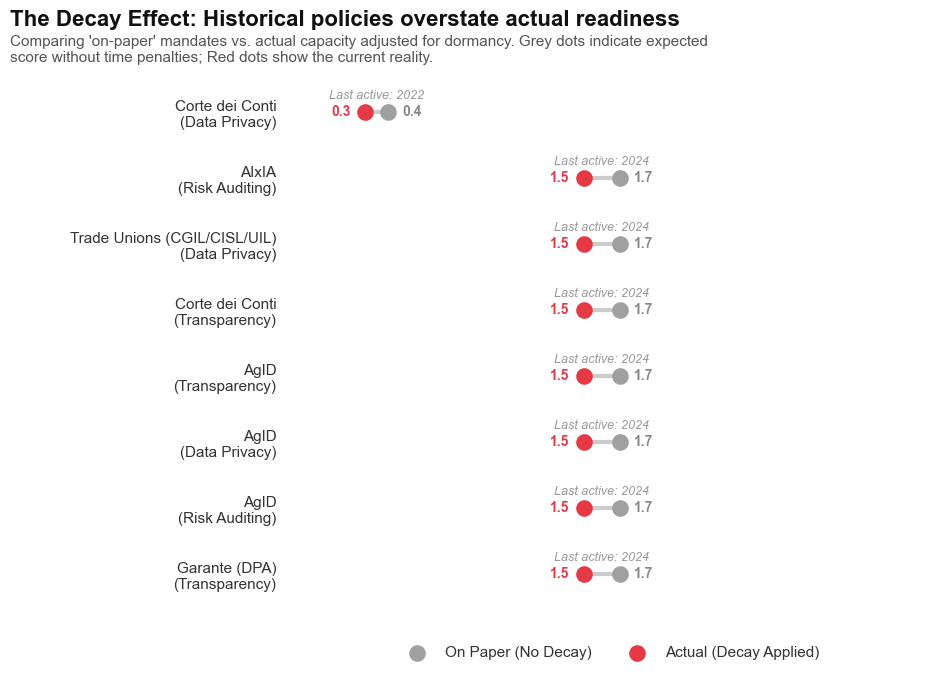


Audit Trail: Cells where temporal decay changed the score by > 0.05:
  Garante (DPA) × (Transparency)      naive=1.70  temporal=1.50  (Δ-0.20, last=2024)
  AgID × (Risk Auditing)              naive=1.70  temporal=1.50  (Δ-0.20, last=2024)
  AgID × (Data Privacy)               naive=1.70  temporal=1.50  (Δ-0.20, last=2024)
  AgID × (Transparency)               naive=1.70  temporal=1.50  (Δ-0.20, last=2024)
  Corte dei Conti × (Transparency)    naive=1.70  temporal=1.50  (Δ-0.20, last=2024)
  Trade Unions (CGIL/CISL/UIL) × (Data Privacy) naive=1.70  temporal=1.50  (Δ-0.20, last=2024)
  AIxIA × (Risk Auditing)             naive=1.70  temporal=1.50  (Δ-0.20, last=2024)
  Corte dei Conti × (Data Privacy)    naive=0.40  temporal=0.27  (Δ-0.13, last=2022)


In [15]:
# ── Visual 3: Before/After Decay Comparison ─────────────────────────────────
# Naïve baseline: mandate + activity_weight (no decay, no reach)

# 1. Recreate Naïve baseline exactly as you had it
naive_data = {
    p: [structured_data[a][p]['mandate'] +
        ACTIVITY_WEIGHTS[structured_data[a][p]['activity_type']]
        for a in actors]
    for p in pillars
}
df_naive = pd.DataFrame(naive_data, index=actors)

# 2. Isolate ONLY the data that changed (The "Delta")
diff = df_temporal - df_naive
changes = []

for actor in actors:
    for pillar in pillars:
        d = diff.at[actor, pillar]
        if d < -0.1:  # Only capture meaningful decay drops
            changes.append({
                'Label': f"{actor}\n({pillar.replace('_', ' ')})",
                'Naive': df_naive.at[actor, pillar],
                'Temporal': df_temporal.at[actor, pillar],
                'Drop': d,
                'Last_Year': structured_data[actor][pillar]['last_year']
            })

# Convert to DataFrame and sort by the largest drop
df_changes = pd.DataFrame(changes).sort_values(by='Drop', ascending=True)

# 3. Setup the Figure
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig4, ax4 = plt.subplots(figsize=(9, 6), facecolor='#FFFFFF')
ax4.set_facecolor('#FFFFFF')

# 4. Plot the Dumbbell Lines & Dots
y_positions = np.arange(len(df_changes))

# Draw the connecting line (The "Drag" of time)
ax4.hlines(y=y_positions, xmin=df_changes['Temporal'], xmax=df_changes['Naive'], 
           color='#CCCCCC', linewidth=3, zorder=1)

# Draw the "Naïve / On Paper" dots (Grey)
ax4.scatter(df_changes['Naive'], y_positions, color='#A0A0A0', s=120, zorder=2, label='On Paper (No Decay)')

# Draw the "Actual / Decayed" dots (Alert Color)
ax4.scatter(df_changes['Temporal'], y_positions, color='#E63946', s=120, zorder=3, label='Actual (Decay Applied)')

# 5. Direct Labeling
for i, row in enumerate(df_changes.itertuples()):
    # Label the starting point (Naive)
    ax4.text(row.Naive + 0.08, i, f"{row.Naive:.1f}", va='center', fontsize=10, color='#888888', fontweight='bold')
    # Label the ending point (Temporal)
    ax4.text(row.Temporal - 0.08, i, f"{row.Temporal:.1f}", va='center', ha='right', fontsize=10, color='#E63946', fontweight='bold')
    # Add context text above the line
    ax4.text((row.Naive + row.Temporal)/2, i + 0.25, f"Last active: {row.Last_Year}", 
             va='center', ha='center', fontsize=9, color='#999999', style='italic')

# 6. Formatting the Axes
ax4.set_yticks(y_positions)
ax4.set_yticklabels(df_changes['Label'], fontsize=11, color='#333333', fontweight='500')
ax4.set_xlim(-0.2, 3.5) # Give breathing room for labels

# 7. Ruthless Cleanup
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.tick_params(axis='both', which='both', length=0)
ax4.set_xticks([]) # Remove X-axis numbers entirely

# 8. Insight-Driven Title Block
fig4.text(-0.05, 1.08, "The Decay Effect: Historical policies overstate actual readiness", 
          fontsize=16, fontweight='bold', color='#111111')
fig4.text(-0.05, 1.02, "Comparing 'on-paper' mandates vs. actual capacity adjusted for dormancy. Grey dots indicate expected\nscore without time penalties; Red dots show the current reality.", 
          fontsize=11, color='#555555')

# Add a clean, unboxed legend
ax4.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=11, labelcolor='#333333')

plt.tight_layout()
plt.savefig('italy_decay_dumbbell.png', dpi=300, bbox_inches='tight')
print('Saved → italy_decay_dumbbell.png ✓')
plt.show()

# Print audit trail (kept intact from your original code)
print("\nAudit Trail: Cells where temporal decay changed the score by > 0.05:")
for row in df_changes.itertuples():
    print(f"  {row.Label.replace(chr(10), ' × '):<35} naive={row.Naive:.2f}  temporal={row.Temporal:.2f}  (Δ{row.Drop:+.2f}, last={row.Last_Year})")

## 4 · Correlation matrix between policy pillars
Shows which governance areas tend to move together across actors — useful for identifying systemic blind spots.

Saved → italy_pillar_correlation_mckinsey.png ✓


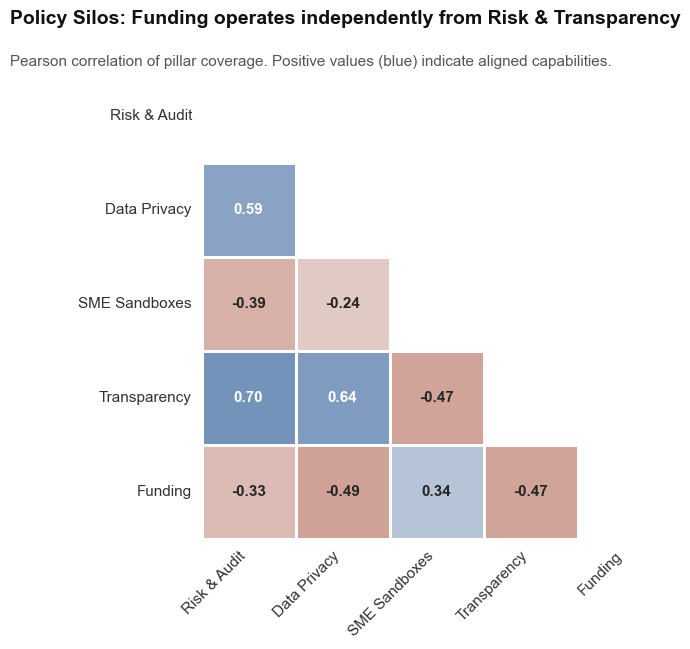

In [16]:
# 1. Calculate Correlation
corr = df.corr(numeric_only=True)

# 2. Create a "Mask" to hide the upper triangle and the diagonal
# This prevents duplicate data and removes the useless 1.00 diagonal line
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Setup Figure with clean white background
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig2, ax2 = plt.subplots(figsize=(7, 6), facecolor='#FFFFFF')
ax2.set_facecolor('#FFFFFF')

# 4. Professional Diverging Palette
# A sophisticated terracotta (negative) to white (neutral) to deep navy (positive)
prof_diverging = sns.diverging_palette(20, 250, s=70, l=45, n=256, as_cmap=True)

# 5. Draw the heatmap
sns.heatmap(
    corr,
    mask=mask,             # Apply the half-triangle mask
    ax=ax2,
    cmap=prof_diverging, 
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 11, 'weight': 'bold'},
    linewidths=2,          # Thicker white grid lines for the "tile" effect
    linecolor='white',
    square=True,
    cbar=False,            # DROP the colorbar (numbers are already directly labeled)
    xticklabels=['Risk & Audit', 'Data Privacy', 'SME Sandboxes', 'Transparency', 'Funding'],
    yticklabels=['Risk & Audit', 'Data Privacy', 'SME Sandboxes', 'Transparency', 'Funding'],
)

# 6. Clean Axes
ax2.tick_params(left=False, bottom=False) # Remove tick marks
plt.xticks(rotation=45, ha='right', fontsize=11, color='#333333', fontweight='500')
plt.yticks(rotation=0, fontsize=11, color='#333333', fontweight='500')

# Remove the empty axes lines caused by the mask
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

# 7. Insight-Driven Title Block (Left Aligned)
# Replace the text below with whatever the strongest correlation in your data actually is
fig2.text(-0.05, 1.05, "Policy Silos: Funding operates independently from Risk & Transparency", 
          fontsize=14, fontweight='bold', color='#111111')
fig2.text(-0.05, 0.98, "Pearson correlation of pillar coverage. Positive values (blue) indicate aligned capabilities.", 
          fontsize=11, color='#555555')

plt.tight_layout()
plt.savefig('italy_pillar_correlation_mckinsey.png', dpi=300, bbox_inches='tight')
print('Saved → italy_pillar_correlation_mckinsey.png ✓')
plt.show()

## 5 · Column averages — quick gap summary

Saved → italy_pillar_averages_mckinsey.png ✓


/var/folders/1b/53hsyqk10y17_2n6h3bm5tn00000gn/T/ipykernel_70195/1861280661.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(col_means.index, fontsize=11, color='#333333', fontweight='500')


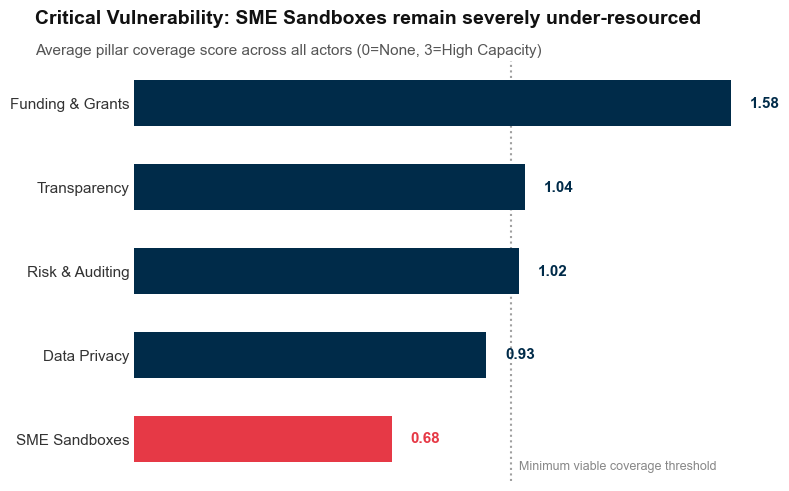

In [17]:
col_means = df.mean(numeric_only=True).rename({
    'Risk_Auditing': 'Risk & Auditing',
    'Data_Privacy': 'Data Privacy',
    'SME_Sandboxes': 'SME Sandboxes',
    'Transparency': 'Transparency',
    'Funding_Grants': 'Funding & Grants',
}).sort_values(ascending=True)

# 2. Setup Figure with clean white background and professional fonts
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig3, ax3 = plt.subplots(figsize=(8, 4.5), facecolor='#FFFFFF')
ax3.set_facecolor('#FFFFFF')

# 3. Strategic Color Palette
# Use a sleek grey for standard bars, and a strong "McKinsey Blue" or Alert color to highlight the lowest gap.
# Here we highlight the lowest scoring pillar to emphasize the vulnerability.
highlight_color = '#E63946'  # Deep Red/Orange for the critical gap (lowest score)
standard_color = '#002B49'   # Corporate Navy for the rest
bar_colors = [highlight_color if i == 0 else standard_color for i in range(len(col_means))]

# 4. Plot the bars
bars = ax3.barh(col_means.index, col_means.values, color=bar_colors, height=0.55)

# 5. Direct Labeling & Clean up
for bar, val in zip(bars, col_means.values):
    # Place text directly at the end of the bar
    # Using bold font for the labels makes them pop without needing an axis
    ax3.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=11, fontweight='bold', color=bar.get_facecolor())

# 6. Insight-Driven Title (Left Aligned)
# Replace the placeholder text below with the actual narrative insight of your data
fig3.text(0.05, 1.05, "Critical Vulnerability: SME Sandboxes remain severely under-resourced", 
          fontsize=14, fontweight='bold', color='#111111')
fig3.text(0.05, 0.98, "Average pillar coverage score across all actors (0=None, 3=High Capacity)", 
          fontsize=11, color='#555555')

# 7. Add a subtle baseline / threshold line (Optional, but cleaner than a legend)
ax3.axvline(1.0, color='#A0A0A0', lw=1.5, ls=':', zorder=0)
ax3.text(1.02, ax3.get_ylim()[0] + 0.1, 'Minimum viable coverage threshold', 
         color='#888888', fontsize=9, va='bottom')

# 8. Ruthless Axis Cleanup (Remove everything unnecessary)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False) # Remove left spine too for a floating look

ax3.tick_params(axis='both', which='both', length=0) # Remove tick marks
ax3.set_xticks([]) # Remove X-axis numbers entirely
ax3.set_yticklabels(col_means.index, fontsize=11, color='#333333', fontweight='500')

plt.tight_layout()
plt.savefig('italy_pillar_averages_mckinsey.png', dpi=300, bbox_inches='tight')
print('Saved → italy_pillar_averages_mckinsey.png ✓')
plt.show()

---
**Outputs:** `italy_heatmap.png` · `italy_pillar_correlation.png` · `italy_pillar_averages.png` · `italy_ai_governance.csv`

**Key cold spots (score 0):**
- CDP × Risk Auditing → major funder, zero risk framework
- SME Networks × SME Sandboxes → legally mandated but unfunded in Italy
- SME Networks × Transparency → no algorithmic disclosure norms for PMIs
- Fondazione Leonardo × SME Sandboxes → untapped policy bridge opportunity